# Emotion classification from text (RoBERTa-base)



## 1. Setup

In [ ]:
# Import libraries
import os
import re
import random
import warnings
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from datasets import load_dataset
from transformers import (
    AutoTokenizer,                       # BPE tokenizer for RoBERTa
    AutoModelForSequenceClassification,  # RoBERTa encoder + classification head
    get_linear_schedule_with_warmup,     # LR scheduler standard for BERT fine-tuning
)

from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    confusion_matrix,
    classification_report,
    f1_score,
)

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")

# Reproducibility
SEED = 25654450
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cuda


In [ ]:
# Load dataset
raw = load_dataset("mteb/emotion")

## 2. EDA


In [ ]:
train_df = raw["train"].to_pandas()
val_df   = raw["validation"].to_pandas()
test_df  = raw["test"].to_pandas()

print("Columns:", train_df.columns.tolist())
print(f"\nRows — train: {len(train_df)} | val: {len(val_df)} | test: {len(test_df)}")
print("\nFirst rows (train):")
display(train_df.head(3))

Columns: ['text', 'label', 'label_text']

Rows — train: 15956 | val: 1988 | test: 1986

First rows (train):


,text,label,label_text
0,i didnt feel humiliated,0,sadness
1,i can go from feeling so hopeless to so damned...,0,sadness
2,im grabbing a minute to post i feel greedy wrong,3,anger


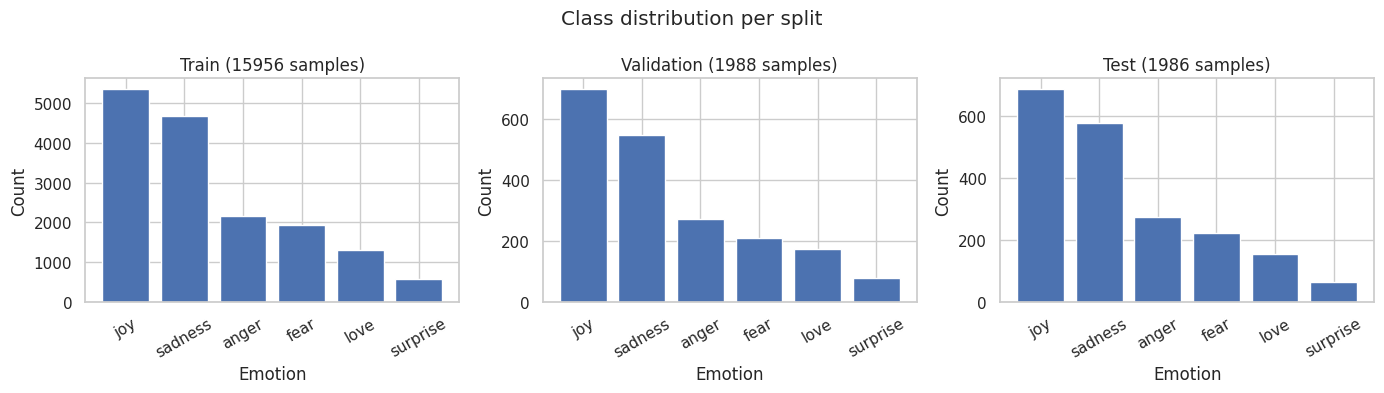


Word count stats (train):
count    15956.0
mean        19.2
std         11.0
min          3.0
25%         11.0
50%         17.0
75%         25.0
max         66.0
Name: word_count, dtype: float64


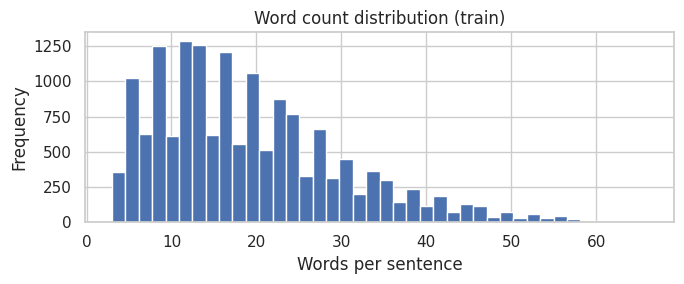

In [ ]:
# --- Class distribution ---
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, (df, title) in zip(
    axes,
    [(train_df, "Train"), (val_df, "Validation"), (test_df, "Test")],
):
    counts = df["label_text"].value_counts()
    ax.bar(counts.index, counts.values)
    ax.set_title(f"{title} ({len(df)} samples)")
    ax.set_xlabel("Emotion")
    ax.set_ylabel("Count")
    ax.tick_params(axis="x", rotation=30)
plt.suptitle("Class distribution per split")
plt.tight_layout()
plt.show()

# --- Text length distribution ---
train_df["word_count"] = train_df["text"].map(lambda s: len(s.split()))
print("\nWord count stats (train):")
print(train_df["word_count"].describe().round(1))

plt.figure(figsize=(7, 3))
plt.hist(train_df["word_count"], bins=40, edgecolor="white")
plt.title("Word count distribution (train)")
plt.xlabel("Words per sentence")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

## 3. Tokenizer

In [ ]:
# Model identifier on the HuggingFace Hub
MODEL_NAME = "roberta-base"

# max_length: cap sequences at 128 BPE tokens.
MAX_LEN = 128

# Load the pre-trained BPE tokenizer for RoBERTa-base
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

print("Tokenizer class :", type(tokenizer).__name__)
print("Vocab size       :", tokenizer.vocab_size)
print("Max model length :", tokenizer.model_max_length)

Tokenizer class : RobertaTokenizer
Vocab size       : 50265
Max model length : 512


In [ ]:
# Preview tokenisation on a sample sentence to understand the output format.
sample_text = train_df["text"].iloc[69]

encoding = tokenizer(
    sample_text,
    max_length=MAX_LEN,
    padding="max_length",
    truncation=True,
    return_tensors="pt",
)

print("Original text  :", sample_text)
print()
print("BPE tokens     :", tokenizer.convert_ids_to_tokens(encoding["input_ids"][0]))
print()
print("input_ids      :", encoding["input_ids"][0].tolist())
print()
print("attention_mask :", encoding["attention_mask"][0].tolist())
print()

print("token_type_ids : not used by RoBERTa (NSP objective removed)")
print()
print("Sequence length after padding/truncation:", encoding["input_ids"].shape[1])

Original text  : i was feeling brave when i bought it and clearly when i was doing my makeup

BPE tokens     : ['<s>', 'i', 'Ġwas', 'Ġfeeling', 'Ġbrave', 'Ġwhen', 'Ġi', 'Ġbought', 'Ġit', 'Ġand', 'Ġclearly', 'Ġwhen', 'Ġi', 'Ġwas', 'Ġdoing', 'Ġmy', 'Ġmakeup', '</s>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad

## 4. Label preparation

In [ ]:
labels_sorted = sorted(train_df["label"].unique())
assert labels_sorted == list(range(len(labels_sorted))), "Labels should be 0..K-1"
num_classes = len(labels_sorted)
id2label = train_df.drop_duplicates("label").set_index("label")["label_text"].to_dict()
label2id = {v: k for k, v in id2label.items()}
print("num_classes:", num_classes)
print("id2label   :", id2label)

num_classes: 6
id2label   : {0: 'sadness', 3: 'anger', 2: 'love', 5: 'surprise', 4: 'fear', 1: 'joy'}


## 5. Split dataset


In [ ]:
# RoBERTa's tokenizer handles all normalisation internally
train_texts = train_df["text"].tolist()
val_texts   = val_df["text"].tolist()
test_texts  = test_df["text"].tolist()

y_train = train_df["label"].to_numpy()
y_val   = val_df["label"].to_numpy()
y_test  = test_df["label"].to_numpy()

print("Split sizes:", len(train_texts), len(val_texts), len(test_texts))

Split sizes: 15956 1988 1986


## 6. Tokenisation & encoding

In [ ]:
def batch_encode(texts, tokenizer, max_len):

    # Tokenise a list of texts and return padded / truncated encodings.
    enc = tokenizer(
        texts,
        max_length=max_len,
        padding="max_length",        # pad all sequences to exactly max_len
        truncation=True,             # truncate sequences longer than max_len
        return_tensors="pt",         # return PyTorch tensors directly
        return_token_type_ids=False, # not needed for RoBERTa
    )
    return {
        "input_ids":      enc["input_ids"],       # (N, max_len)
        "attention_mask": enc["attention_mask"],   # (N, max_len)
    }


print("Encoding train split...")
enc_train = batch_encode(train_texts, tokenizer, MAX_LEN)

print("Encoding validation split...")
enc_val = batch_encode(val_texts, tokenizer, MAX_LEN)

print("Encoding test split...")
enc_test = batch_encode(test_texts, tokenizer, MAX_LEN)

print()
print("Shapes:")
print("  input_ids  train:", enc_train["input_ids"].shape)
print("  input_ids  val  :", enc_val["input_ids"].shape)
print("  input_ids  test :", enc_test["input_ids"].shape)

Encoding train split...
Encoding validation split...
Encoding test split...

Shapes:
  input_ids  train: torch.Size([15956, 128])
  input_ids  val  : torch.Size([1988, 128])
  input_ids  test : torch.Size([1986, 128])


## 7. PyTorch Dataset / DataLoader

In [ ]:
class EmotionDataset(Dataset):

    # Wraps pre-computed tokeniser encodings and integer labels into a PyTorch Dataset.
    def __init__(self, encodings, labels):
        # encodings: dict with 'input_ids' and 'attention_mask' tensors
        self.input_ids      = encodings["input_ids"]
        self.attention_mask = encodings["attention_mask"]
        self.labels         = torch.tensor(labels, dtype=torch.long)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, i):
        return (
            self.input_ids[i],       # (max_len,)
            self.attention_mask[i],  # (max_len,)
            self.labels[i],          # scalar
        )


def make_loader(encodings, labels, batch_size, shuffle):
    ds = EmotionDataset(encodings, labels)
    return DataLoader(ds, batch_size=batch_size, shuffle=shuffle)

BATCH_SIZE = 32

train_loader = make_loader(enc_train, y_train, BATCH_SIZE, shuffle=True)
val_loader   = make_loader(enc_val,   y_val,   BATCH_SIZE, shuffle=False)
test_loader  = make_loader(enc_test,  y_test,  BATCH_SIZE, shuffle=False)

In [ ]:
def count_params(m):
    # Count number of parameters
    return sum(p.numel() for p in m.parameters() if p.requires_grad)


# AutoModelForSequenceClassification automatically attaches a classification head
# (dropout + linear layer) on top of the pooled <s> (CLS) token representation.
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=num_classes,
    id2label=id2label,
    label2id=label2id,
).to(device)

print("Model            :", type(model).__name__)
print("Trainable params :", f"{count_params(model):,}")

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
classifier.out_proj.bias        | MISSING    | 
classifier.dense.weight         | MISSING    | 
classifier.out_proj.weight      | MISSING    | 
classifier.dense.bias           | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Model            : RobertaForSequenceClassification
Trainable params : 124,650,246


In [ ]:
# Quick sanity check: one forward pass to verify output shapes
input_ids_demo, mask_demo, _ = next(iter(train_loader))
with torch.no_grad():
    out = model(
        input_ids=input_ids_demo.to(device),
        attention_mask=mask_demo.to(device),
    )

# AutoModelForSequenceClassification returns a SequenceClassifierOutput dataclass.
print("Output type  :", type(out).__name__)
print("Logits shape :", out.logits.shape)  # expected: (BATCH_SIZE, num_classes)

Output type  : SequenceClassifierOutput
Logits shape : torch.Size([32, 6])


## 9. Training — CrossEntropyLoss, AdamW, linear warmup, early stopping on val macro-F1


In [ ]:
# Train the model for one epoch
def train_one_epoch(model, loader, optimizer, scheduler, criterion):

    # Set model to training mode
    # This enables dropout and other training-specific behaviour
    model.train()
    total_loss = 0.0

    # Loop through batches from DataLoader
    for input_ids, attention_mask, labels in loader:
        input_ids      = input_ids.to(device)
        attention_mask = attention_mask.to(device)
        labels         = labels.to(device)

        optimizer.zero_grad(set_to_none=True)

        # Forward pass: model returns a SequenceClassifierOutput dataclass
        output = model(input_ids=input_ids, attention_mask=attention_mask)
        logits = output.logits  # (B, num_classes)

        # Compute loss between predicted logits and true labels
        loss = criterion(logits, labels)

        # Backpropagation: compute gradients
        loss.backward()

        # Gradient clipping helps stabilise transformer fine-tuning
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

        # Update model parameters
        optimizer.step()

        # Step the LR scheduler once per batch (transformer convention)
        scheduler.step()

        # Accumulate total loss weighted by batch size
        total_loss += loss.item() * input_ids.size(0)

    # Return average loss over the whole training set
    return total_loss / len(loader.dataset)


# Evaluate model on validation or test set
@torch.no_grad()
def evaluate(model, loader, criterion=None):

    # Set model to evaluation mode - disables dropout
    model.eval()
    total_loss = 0.0
    all_y, all_p = [], []

    for input_ids, attention_mask, labels in loader:
        input_ids      = input_ids.to(device)
        attention_mask = attention_mask.to(device)
        labels         = labels.to(device)

        # Forward pass
        output = model(input_ids=input_ids, attention_mask=attention_mask)
        logits = output.logits  # (B, num_classes)

        # Compute loss only if criterion is provided
        if criterion is not None:
            total_loss += criterion(logits, labels).item() * input_ids.size(0)

        # Predicted class = index of highest logit
        all_p.append(logits.argmax(dim=-1).cpu().numpy())

        # Store true labels
        all_y.append(labels.cpu().numpy())

    # Merge all batches into full arrays
    y_true = np.concatenate(all_y)
    y_pred = np.concatenate(all_p)

    # Compute evaluation metrics
    metrics = {
        "acc":         accuracy_score(y_true, y_pred),
        "macro_f1":    f1_score(y_true, y_pred, average="macro"),
        "weighted_f1": f1_score(y_true, y_pred, average="weighted"),
    }

    # Add average loss if criterion was used
    if criterion is not None:
        metrics["loss"] = total_loss / len(loader.dataset)

    return metrics, y_true, y_pred


# Training loop flow:
def train_model(
    model,
    train_loader,
    val_loader,
    epochs=30,
    lr=2e-5,
    weight_decay=0.01,
    warmup_ratio=0.1,  # fraction of total steps used for linear LR warmup
    patience=5,        # stop if val macro-F1 does not improve for this many epochs
):
    criterion = nn.CrossEntropyLoss()

    # Optimizer: AdamW with selective weight decay
    no_decay = {"bias", "LayerNorm.weight"}
    param_groups = [
        {
            # All parameters whose names do NOT contain 'bias' or 'LayerNorm.weight'
            "params": [
                p for n, p in model.named_parameters()
                if not any(nd in n for nd in no_decay)
            ],
            "weight_decay": weight_decay,
        },
        {
            # Bias and LayerNorm parameters: no weight decay
            "params": [
                p for n, p in model.named_parameters()
                if any(nd in n for nd in no_decay)
            ],
            "weight_decay": 0.0,
        },
    ]
    optimizer = torch.optim.AdamW(param_groups, lr=lr)

    # Scheduler: linear warmup then linear decay
    total_steps  = len(train_loader) * epochs
    warmup_steps = int(total_steps * warmup_ratio)
    scheduler = get_linear_schedule_with_warmup(
        optimizer,
        num_warmup_steps=warmup_steps,
        num_training_steps=total_steps,
    )
    print(f"Total steps: {total_steps} | Warmup steps: {warmup_steps}")

    # Store training history for plotting later
    history  = {"train_loss": [], "val_loss": [], "val_macro_f1": [], "val_acc": []}

    # Track best model according to validation macro-F1
    best_state = None
    best_f1    = -1.0
    stale      = 0  # number of epochs without improvement

    for ep in range(1, epochs + 1):
        # Train one epoch
        tl = train_one_epoch(model, train_loader, optimizer, scheduler, criterion)

        # Evaluate on validation set
        vm, _, _ = evaluate(model, val_loader, criterion)

        # Save current metrics
        history["train_loss"].append(tl)
        history["val_loss"].append(vm["loss"])
        history["val_macro_f1"].append(vm["macro_f1"])
        history["val_acc"].append(vm["acc"])

        # Check whether validation macro-F1 improved
        if vm["macro_f1"] > best_f1 + 1e-5:
            best_f1 = vm["macro_f1"]

            # Save a copy of the best model weights (moved to CPU to free GPU memory)
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            stale = 0
        else:
            stale += 1

        # Print progress every epoch
        if ep == 1 or ep % 1 == 0 or stale == 0:
            print(
                f"Epoch {ep:02d} "
                f"train_loss={tl:.4f} "
                f"val_loss={vm['loss']:.4f} "
                f"val_acc={vm['acc']:.4f} "
                f"val_macro_f1={vm['macro_f1']:.4f}"
            )

        # Stop early if no improvement for 'patience' epochs
        if stale >= patience:
            print(
                f"Early stopping at epoch {ep} "
                f"(no val macro-F1 improvement for {patience} epochs)."
            )
            break

    # Restore best model weights before returning
    if best_state is not None:
        model.load_state_dict(best_state)

    return history, best_f1


# Plot training curves
def plot_history(history, title="Training"):
    fig, ax = plt.subplots(1, 2, figsize=(9, 3))

    # Plot train/validation loss
    ax[0].plot(history["train_loss"], label="train")
    ax[0].plot(history["val_loss"],   label="val")
    ax[0].set_title("Loss")
    ax[0].legend()

    # Plot validation metrics
    ax[1].plot(history["val_macro_f1"], label="val macro-F1")
    ax[1].plot(history["val_acc"],      label="val acc", alpha=0.6)
    ax[1].set_title("Val metrics")
    ax[1].legend()

    plt.suptitle(title)
    plt.tight_layout()
    plt.show()

## 10. Train RoBERTa-base

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
classifier.out_proj.bias        | MISSING    | 
classifier.dense.weight         | MISSING    | 
classifier.out_proj.weight      | MISSING    | 
classifier.dense.bias           | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Total steps: 14970 | Warmup steps: 1497
Epoch 01 train_loss=1.3194 val_loss=0.5458 val_acc=0.8179 val_macro_f1=0.7034
Epoch 02 train_loss=0.3928 val_loss=0.2955 val_acc=0.8999 val_macro_f1=0.8760
Epoch 03 train_loss=0.2130 val_loss=0.1845 val_acc=0.9366 val_macro_f1=0.9137
Epoch 04 train_loss=0.1604 val_loss=0.1500 val_acc=0.9371 val_macro_f1=0.9093
Epoch 05 train_loss=0.1269 val_loss=0.1346 val_acc=0.9401 val_macro_f1=0.9157
Epoch 06 train_loss=0.1088 val_loss=0.1425 val_acc=0.9422 val_macro_f1=0.9161
Epoch 07 train_loss=0.0984 val_loss=0.1468 val_acc=0.9356 val_macro_f1=0.9072
Epoch 08 train_loss=0.0880 val_loss=0.1856 val_acc=0.9437 val_macro_f1=0.9174
Epoch 09 train_loss=0.0771 val_loss=0.2337 val_acc=0.9442 val_macro_f1=0.9175
Epoch 10 train_loss=0.0601 val_loss=0.2681 val_acc=0.9406 val_macro_f1=0.9116
Epoch 11 train_loss=0.0486 val_loss=0.3032 val_acc=0.9391 val_macro_f1=0.9130
Epoch 12 train_loss=0.0448 val_loss=0.2960 val_acc=0.9472 val_macro_f1=0.9242
Epoch 13 train_loss=0.03

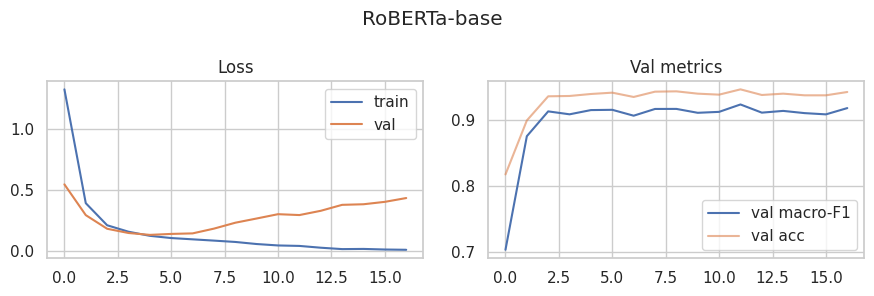

In [ ]:
# Re-initialise model to ensure clean weights before training.

model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=num_classes,
    id2label=id2label,
    label2id=label2id,
).to(device)

history, best_val_f1 = train_model(
    model,
    train_loader,
    val_loader,
    epochs=30,
    lr=2e-5,
    weight_decay=0.01,
    warmup_ratio=0.1,
    patience=5,
)

print(f"\nBest val macro-F1 (main): {best_val_f1}")
plot_history(history, title="RoBERTa-base")

## 11. Evaluation

=== Validation RoBERTa-base ===
Accuracy: 0.9471830985915493

Per-class metrics:


,precision,recall,f1
sadness,0.9574,0.9800,0.9686
joy,0.9711,0.9600,0.9655
love,0.8587,0.9133,0.8852
anger,0.9696,0.9307,0.9497
fear,0.8869,0.9289,0.9074
surprise,0.9692,0.7875,0.8690



Macro    F1: 0.9242
Weighted F1: 0.9471

Full classification report:
              precision    recall  f1-score   support

     sadness       0.96      0.98      0.97       550
         joy       0.97      0.96      0.97       700
        love       0.86      0.91      0.89       173
       anger       0.97      0.93      0.95       274
        fear       0.89      0.93      0.91       211
    surprise       0.97      0.79      0.87        80

    accuracy                           0.95      1988
   macro avg       0.94      0.92      0.92      1988
weighted avg       0.95      0.95      0.95      1988



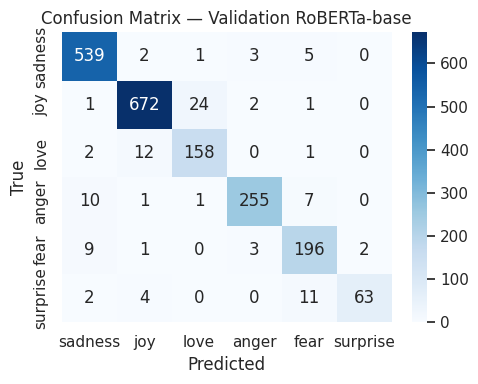

array([[539,   2,   1,   3,   5,   0],
       [  1, 672,  24,   2,   1,   0],
       [  2,  12, 158,   0,   1,   0],
       [ 10,   1,   1, 255,   7,   0],
       [  9,   1,   0,   3, 196,   2],
       [  2,   4,   0,   0,  11,  63]])

In [ ]:
def full_report(y_true, y_pred, split_name="val"):

    # Create class names in label-id order
    names = [id2label[i] for i in sorted(id2label.keys())]

    # Print split name
    print(f"=== {split_name} ===")

    # Print overall accuracy
    print("Accuracy:", accuracy_score(y_true, y_pred))

    # Compute per-class precision, recall, and F1
    # average=None means return metric for each class separately
    p, r, f1, _ = precision_recall_fscore_support(
        y_true,
        y_pred,
        average=None,
        labels=sorted(id2label.keys()),
    )

    # Assemble per-class metrics into a DataFrame for readability
    metrics_df = pd.DataFrame(
        {"precision": p, "recall": r, "f1": f1},
        index=names,
    ).round(4)
    print("\nPer-class metrics:")
    display(metrics_df)

    # Print macro and weighted averages
    print("\nMacro    F1:", round(f1_score(y_true, y_pred, average="macro"),    4))
    print("Weighted F1:", round(f1_score(y_true, y_pred, average="weighted"), 4))

    # Full sklearn classification report
    print("\nFull classification report:")
    print(classification_report(y_true, y_pred, target_names=names))

    # Confusion matrix
    cm = confusion_matrix(y_true, y_pred, labels=sorted(id2label.keys()))

    plt.figure(figsize=(5, 4))
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        xticklabels=names,
        yticklabels=names,
        cmap="Blues",
    )
    plt.title(f"Confusion Matrix — {split_name}")
    plt.ylabel("True")
    plt.xlabel("Predicted")
    plt.tight_layout()
    plt.show()

    return cm


# Evaluate the trained model on the validation set
_, yv_t, yv_p = evaluate(model, val_loader, nn.CrossEntropyLoss())
full_report(yv_t, yv_p, "Validation RoBERTa-base")

## 12. Error analysis


In [ ]:
# Run evaluation on the validation set
_, yv_t, yv_p = evaluate(model, val_loader, None)

# Create ordered class names from label ids
names = [id2label[i] for i in sorted(id2label.keys())]

# Build confusion matrix
cm = confusion_matrix(yv_t, yv_p, labels=sorted(id2label.keys()))

# Find the most common confusion pairs
pairs = []
n = cm.shape[0]
for i in range(n):
    for j in range(n):
        if i != j and cm[i, j] > 0:
            pairs.append((cm[i, j], names[i], names[j]))
pairs.sort(reverse=True)

# Print the most frequent confusion types
print("Top confused (true -> pred):")
for c, a, b in pairs[:8]:
    print(f"  {c:4d}  {a} -> {b}")

# Show some actual misclassified validation examples
val_texts_arr = val_df["text"].to_numpy()
wrong_idx = np.where(yv_t != yv_p)[0]
sample = np.random.default_rng(SEED).choice(wrong_idx, size=min(12, len(wrong_idx)), replace=False)
print("\nSample errors (val):")
for i in sample:
    print(f"\n true={names[yv_t[i]]} pred={names[yv_p[i]]}")
    print(" ", val_texts_arr[i][:280])

Top confused (true -> pred):
    24  joy -> love
    12  love -> joy
    11  surprise -> fear
    10  anger -> sadness
     9  fear -> sadness
     7  anger -> fear
     5  sadness -> fear
     4  surprise -> joy

Sample errors (val):

 true=love pred=joy
  i feel gracious what about you

 true=fear pred=sadness
  that day i was alone at home after coming home from school i did not know where everyone else had gone

 true=joy pred=love
  i get this overwhelming feeling that i am truly blessed

 true=anger pred=sadness
  i know what it feels like he stressed glaring down at her as she squeezed more soap onto her sponge

 true=joy pred=love
  i have stayed at heritage christian because of the fulfillment that i feel in doing christ s work in action by being the hands the eyes the legs and the voice of supporting the individuals that i have been blessed to know and support

 true=joy pred=love
  i have been a pro at hiding my true feelings but the cracks are coming through so i am going t